Import Libraries

In [157]:
import sys
sys.path.append("../src")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from db_connection import DatabaseConnector
from queries import NBAReceiverQuaries
from data_loader import NBADataLoader

from descriptive_statistics import DescriptiveStatistics
from statistical_tests import StatisticalTester
from effect_size import EffectSizeCalculator
from confidence_interval import ConfidenceIntervalCalculator

Database Connection

In [158]:
db = DatabaseConnector(env_path="../.env")
engine = db.create_connection()

Load Data

In [159]:
loader = NBADataLoader(engine)

df_agility = loader.load_agility_data(
    NBAReceiverQuaries.query_agility
)

df_intrinsic = loader.load_intrinsic_data(
    NBAReceiverQuaries.query_intrinsic
)

Initialize Statistical Tester

In [160]:
tester = StatisticalTester(alpha=0.05)

Hypothesis 1/ Prepare Data

In [161]:
past = df_agility[
    df_agility["period_group"] == "past_period"
]["agility"]

recent = df_agility[
    df_agility["period_group"] == "recent_period"
]["agility"]

Descriptive Statistics

In [162]:
past_summary = DescriptiveStatistics.summarize(past)
recent_summary = DescriptiveStatistics.summarize(recent)

pd.DataFrame(
    [past_summary, recent_summary],
    index=["Past Period", "Recent Period"]
)

,sample_size,mean,std,min,q1,median,q3,max
Past Period,23,0.358747,0.035429,0.3,0.335511,0.350000,0.380476,0.425287
Recent Period,18,0.366941,0.033611,0.3,0.341590,0.363393,0.397368,0.425287


Hypothesis Test

In [163]:
agility_result = tester.run_hypothesis_test(
    df=df_agility,
    value_column="agility",
    hypothesis_name="Agility of Top 20 MVP Candidates",
    group_column="period_group"
)

tester.print_report(agility_result)

Hypothesis Test Report: Agility of Top 20 MVP Candidates

Value Column:
agility

Sample Sizes:
Past period: 23
Recent period: 18

Means:
Past mean: 0.35874697154208784
Recent mean: 0.3669407438782334
Mean difference: 0.008193772336145544

Normality Test - Past Period:
{'test': 'Shapiro-Wilk', 'statistic': np.float64(0.9610091173742892), 'p_value': np.float64(0.4840469030421829), 'is_normal': np.True_}

Normality Test - Recent Period:
{'test': 'Shapiro-Wilk', 'statistic': np.float64(0.9072326045430256), 'p_value': np.float64(0.07690352308312025), 'is_normal': np.True_}

Selected Test:
welch

Test Result:
{'test': 'Welch independent t-test', 'alternative': 'recent > past', 'statistic': np.float64(0.7564315021749917), 'p_value': np.float64(0.2270579994043617), 'is_significant': np.False_}

Description:
از آنجا که مقدار p-value برابر با 0.2271 است و از سطح معناداری alpha = 0.05 بزرگ‌تر یا مساوی می‌باشد، فرض صفر رد نمی‌شود.
بنابراین شواهد آماری کافی وجود ندارد که نتیجه بگیریم مقدار متغیر مو

Effect Size

In [164]:
effect_agility = EffectSizeCalculator.calculate_cohens_d(
    recent,
    past
)

effect_agility

{'method': "Cohen's d",
 'effect_size': 0.23648412206323405,
 'absolute_effect_size': 0.23648412206323405,
 'interpretation': 'Small Effect',
 'group1_size': 18,
 'group2_size': 23}

Confidence Interval

In [165]:
ci_agility = ConfidenceIntervalCalculator.mean_difference_ci(
    recent,
    past
)

ci_agility

{'method': 'Mean Difference Confidence Interval',
 'confidence_level': 0.95,
 'mean_difference': 0.008193772336145544,
 'lower_bound': -0.013744244513178246,
 'upper_bound': 0.030131789185469333,
 'sample_size_group1': 18,
 'sample_size_group2': 23}

Agility of Top 20 MVP Candidates

<Axes: xlabel='period_group', ylabel='agility'>

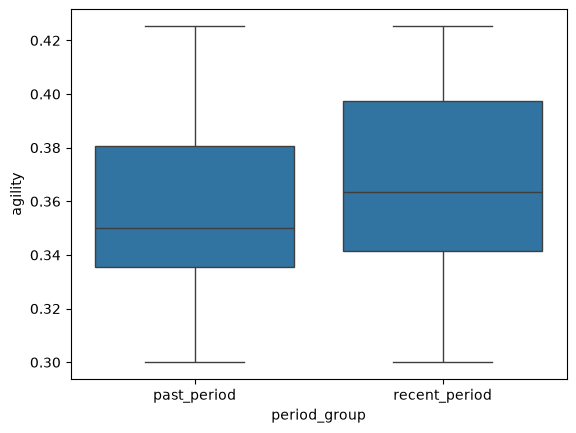

In [166]:
sns.boxplot(
    data=df_agility,
    x="period_group",
    y="agility"
)

<Axes: xlabel='period_group', ylabel='agility'>

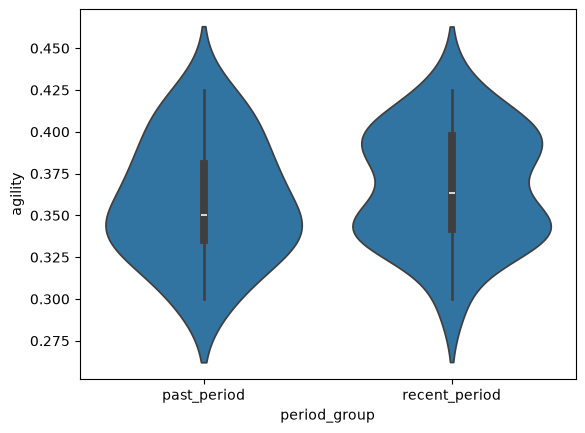

In [167]:
sns.violinplot(
    data=df_agility,
    x="period_group",
    y="agility",
    inner="box"
)

<Axes: xlabel='agility', ylabel='Density'>

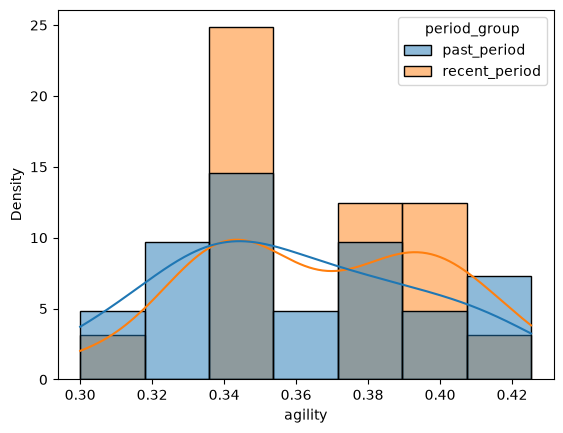

In [168]:
sns.histplot(
    data=df_agility,
    x="agility",
    hue="period_group",
    kde=True,
    stat="density",
    common_norm=False
)

<Axes: xlabel='period_group', ylabel='agility'>

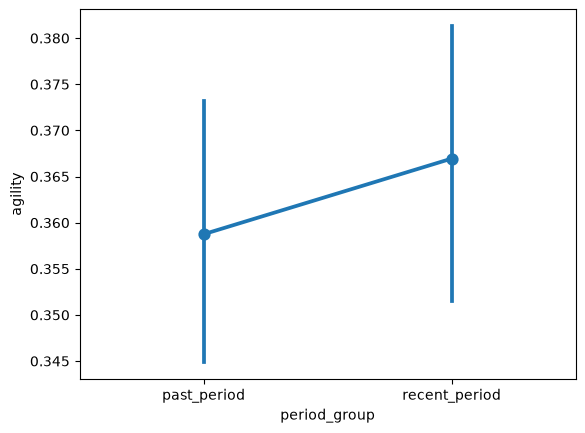

In [169]:
sns.pointplot(
    data=df_agility,
    x="period_group",
    y="agility",
    errorbar=("ci",95)
)

<Axes: xlabel='period_group', ylabel='agility'>

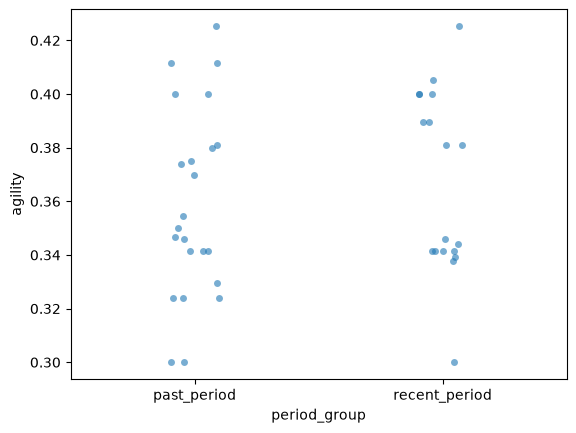

In [170]:
sns.stripplot(
    data=df_agility,
    x="period_group",
    y="agility",
    alpha=.6
)

Hypothesis 2/ Prepare Data

In [171]:
past = df_intrinsic[
    df_intrinsic["period_group"] == "past_period"
]["intrinsic_talent"]

recent = df_intrinsic[
    df_intrinsic["period_group"] == "recent_period"
]["intrinsic_talent"]

Descriptive Statistics

In [172]:
past_summary = DescriptiveStatistics.summarize(past)
recent_summary = DescriptiveStatistics.summarize(recent)

pd.DataFrame(
    [past_summary, recent_summary],
    index=["Past Period", "Recent Period"]
)

,sample_size,mean,std,min,q1,median,q3,max
Past Period,72,0.162334,0.102301,0.04,0.086051,0.130435,0.230769,0.428571
Recent Period,110,0.208309,0.120391,0.04,0.115385,0.192308,0.299074,0.444444


Hypothesis Test

In [173]:
intrinsic_result = tester.run_hypothesis_test(
    df=df_intrinsic,
    value_column="intrinsic_talent",
    hypothesis_name="Comparison of intrinsic talent between players of past and recent periods",
    group_column="period_group"
)

tester.print_report(intrinsic_result)

Hypothesis Test Report: Comparison of intrinsic talent between players of past and recent periods

Value Column:
intrinsic_talent

Sample Sizes:
Past period: 72
Recent period: 110

Means:
Past mean: 0.16233394210178834
Recent mean: 0.20830947442313213
Mean difference: 0.0459755323213438

Normality Test - Past Period:
{'test': 'Shapiro-Wilk', 'statistic': np.float64(0.9005309493791748), 'p_value': np.float64(3.213795703750859e-05), 'is_normal': np.False_}

Normality Test - Recent Period:
{'test': 'Shapiro-Wilk', 'statistic': np.float64(0.9369473361203006), 'p_value': np.float64(5.742119210619375e-05), 'is_normal': np.False_}

Selected Test:
mannwhitney

Test Result:
{'test': 'Mann-Whitney U test', 'alternative': 'recent > past', 'statistic': np.float64(4862.0), 'p_value': np.float64(0.00473278882258946), 'is_significant': np.True_}

Description:
از آنجا که مقدار p-value برابر با 0.0047 است و از سطح معناداری alpha = 0.05 کمتر می‌باشد، فرض صفر رد می‌شود.
بنابراین شواهد آماری معناداری وجود

Effect Size

In [174]:
effect_intrinsic = EffectSizeCalculator.calculate_cohens_d(
    recent,
    past
)

effect_intrinsic

{'method': "Cohen's d",
 'effect_size': 0.404713250500258,
 'absolute_effect_size': 0.404713250500258,
 'interpretation': 'Small Effect',
 'group1_size': 110,
 'group2_size': 72}

Confidence Interval

In [175]:
ci_intrinsic = ConfidenceIntervalCalculator.mean_difference_ci(
    recent,
    past
)

ci_intrinsic

{'method': 'Mean Difference Confidence Interval',
 'confidence_level': 0.95,
 'mean_difference': 0.0459755323213438,
 'lower_bound': 0.013111680362236935,
 'upper_bound': 0.07883938428045066,
 'sample_size_group1': 110,
 'sample_size_group2': 72}

Intrinsic Talent

<Axes: xlabel='period_group', ylabel='intrinsic_talent'>

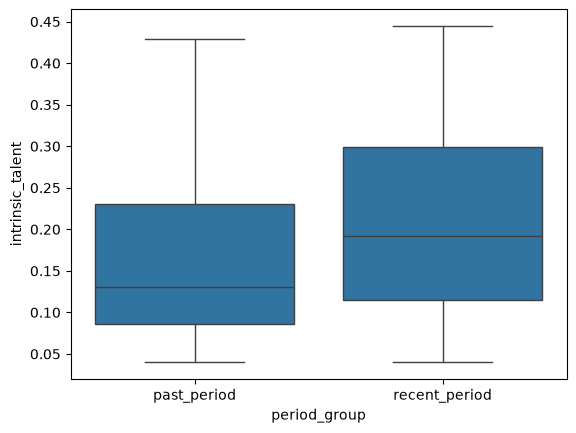

In [176]:
sns.boxplot(
    data=df_intrinsic,
    x="period_group",
    y="intrinsic_talent"
)

<Axes: xlabel='period_group', ylabel='intrinsic_talent'>

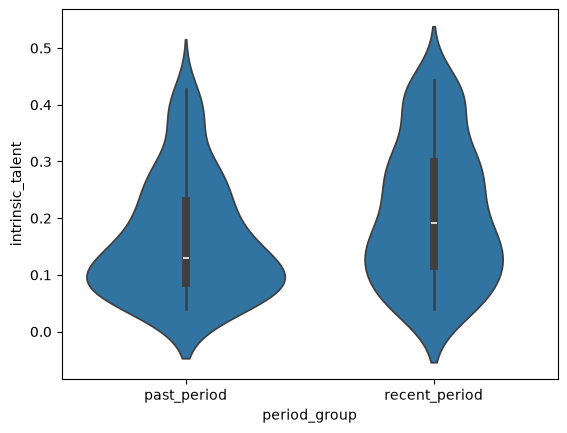

In [177]:
sns.violinplot(
    data=df_intrinsic,
    x="period_group",
    y="intrinsic_talent",
    inner="box"
)

<Axes: xlabel='intrinsic_talent', ylabel='Density'>

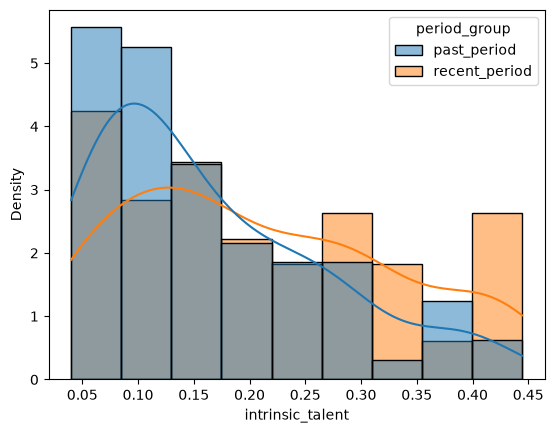

In [178]:
sns.histplot(
    data=df_intrinsic,
    x="intrinsic_talent",
    hue="period_group",
    kde=True,
    stat="density",
    common_norm=False
)

<Axes: xlabel='period_group', ylabel='intrinsic_talent'>

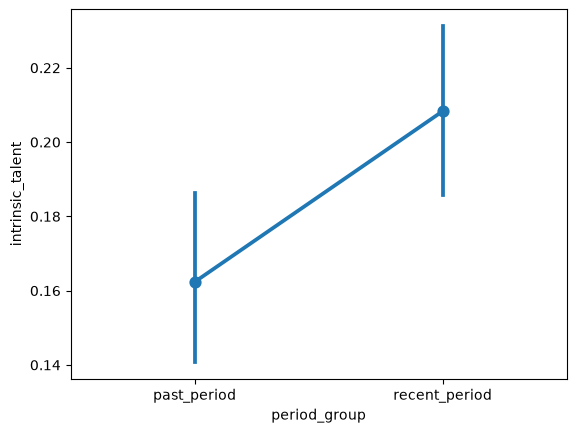

In [179]:
sns.pointplot(
    data=df_intrinsic,
    x="period_group",
    y="intrinsic_talent",
    errorbar=("ci",95)
)